# Predictive Maintenance Machine Learning Project

In [123]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (accuracy_score, confusion_matrix,classification_report)

# Data Loading

In [124]:
df = pd.read_csv("../data/predictive_maintenance.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


# Data Preprocessing

In [125]:
df["Type"] = df["Type"].map({  "L": 0, "M": 1, "H": 2})

df_model = df.drop(["UDI", "Product ID", "Failure Type"],axis=1)

X = df_model.drop("Target", axis=1)
y = df_model["Target"]

# Train Test Split

In [126]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

# Logistic Regression

In [127]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

print("Logistic Regression Accuracy:",
accuracy_score(y_test, lr_predictions))

print(confusion_matrix(y_test, lr_predictions))

print(classification_report(y_test, lr_predictions))

Logistic Regression Accuracy: 0.974
[[1930    9]
 [  43   18]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1939
           1       0.67      0.30      0.41        61

    accuracy                           0.97      2000
   macro avg       0.82      0.65      0.70      2000
weighted avg       0.97      0.97      0.97      2000



# Random Forest

In [128]:
rf_model = RandomForestClassifier( n_estimators=100,random_state=42)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))

print(confusion_matrix(y_test, rf_predictions))

print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.9845
[[1933    6]
 [  25   36]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.86      0.59      0.70        61

    accuracy                           0.98      2000
   macro avg       0.92      0.79      0.85      2000
weighted avg       0.98      0.98      0.98      2000



# Decision Tree

In [129]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

print("Decision Tree Accuracy:",accuracy_score(y_test, dt_predictions))

print(confusion_matrix(y_test, dt_predictions))

print(classification_report(y_test, dt_predictions))

Decision Tree Accuracy: 0.9775
[[1910   29]
 [  16   45]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1939
           1       0.61      0.74      0.67        61

    accuracy                           0.98      2000
   macro avg       0.80      0.86      0.83      2000
weighted avg       0.98      0.98      0.98      2000



# Model Comparison


In [130]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, dt_predictions),
        accuracy_score(y_test, rf_predictions)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.9740
1,Decision Tree,0.9775
2,Random Forest,0.9845


In [131]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,Torque [Nm],0.302840
3,Rotational speed [rpm],0.238668
5,Tool wear [min],0.158054
1,Air temperature [K],0.140315
2,Process temperature [K],0.132750
0,Type,0.027373


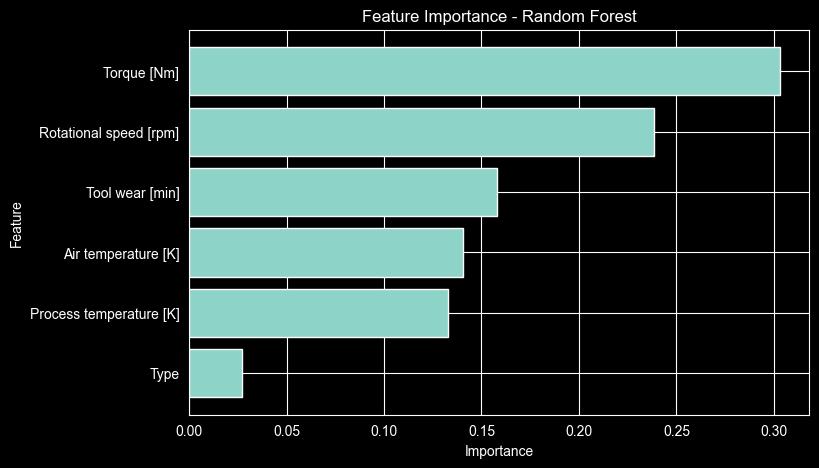

In [132]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()